In [31]:
import os
import sys
import json
import time
from typing import List, Dict, Any, Optional, Literal, TypedDict, Annotated
import operator

In [33]:
# In-memory store inventory for NexusCart AI
MOCK_CATALOG = {
    "all purpose flour": {"sku": "SKU_FLOUR_01", "name": "All-Purpose Flour (500g)", "price_inr": 60, "stock": 15, "is_margin_booster": False},
    "cocoa powder": {"sku": "SKU_COCOA_01", "name": "Baking Cocoa Powder (150g)", "price_inr": 180, "stock": 10, "is_margin_booster": False},
    "sugar": {"sku": "SKU_SUGAR_01", "name": "Granulated Sugar (500g)", "price_inr": 45, "stock": 20, "is_margin_booster": False},
    "baking powder": {"sku": "SKU_BAKE_01", "name": "Baking Powder (100g)", "price_inr": 40, "stock": 8, "is_margin_booster": False},
    "unsalted butter": {"sku": "SKU_BUTTER_01", "name": "Unsalted Butter (200g)", "price_inr": 120, "stock": 5, "is_margin_booster": False},
    "vanilla extract": {"sku": "SKU_VANILLA_01", "name": "Pure Vanilla Extract (50ml)", "price_inr": 220, "stock": 0, "is_margin_booster": False}, # Out of stock for testing
    "cake tin": {"sku": "SKU_TIN_01", "name": "8-inch Non-Stick Cake Tin", "price_inr": 250, "stock": 12, "is_margin_booster": True}, # Upsell
    "birthday candles": {"sku": "SKU_CANDLE_01", "name": "Metallic Birthday Candles (10pk)", "price_inr": 80, "stock": 30, "is_margin_booster": True} # Upsell
}

print("Catalog initialized with", len(MOCK_CATALOG), "items.")
print("Test Lookup: Cocoa Powder costs ₹" + str(MOCK_CATALOG["cocoa powder"]["price_inr"]))

Catalog initialized with 8 items.
Test Lookup: Cocoa Powder costs ₹180


In [34]:
import os
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import List
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# 1. Load the environment variables
load_dotenv()

# 2. Define the Pydantic Schemas
class IngredientItem(BaseModel):
    name: str = Field(description="Normalized ingredient name, e.g., 'all purpose flour'")
    quantity: float = Field(description="Numeric quantity required")
    unit: str = Field(description="Unit of measurement: 'g', 'ml', 'unit', 'tbsp'")

class RecipeExtraction(BaseModel):
    dish_name: str
    servings: int
    is_cooking_or_baking: bool = Field(description="True if the intent involves baking or cooking")
    ingredients: List[IngredientItem]
    instructions: List[str] = Field(description="Step-by-step cooking or baking instructions")

# 3. Initialize Groq with Llama 3.3
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0, 
    api_key=os.getenv("GROQ_API_KEY")
)

# 4. Bulletproof System Prompt with JSON Template
system_prompt = """You are an expert executive chef and grocery planner.
Your job is to break down the user's dish into standard, essential cooking ingredients.

Rules:
- Output ingredient names in lowercase, generic pantry terms that a local grocer carries (e.g., 'granulated sugar').
- Accurately estimate standard recipe quantities scaled to the number of servings.
- Strictly output ingredients, units, and quantities—never calculate prices.

YOU MUST RESPOND ONLY WITH A VALID JSON OBJECT EXACTLY MATCHING THIS STRUCTURE:
{{
  "dish_name": "String (name of the dish)",
  "servings": Integer (number of people),
  "is_cooking_or_baking": Boolean (true or false),
  "ingredients": [
    {{
      "name": "String",
      "quantity": Float,
      "unit": "String"
    }}
  ],
  "instructions": [
    "String (Step 1...)",
    "String (Step 2...)"
  ]
}}"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{user_query}")
])

# 5. Bind schema and chain
structured_llm = llm.with_structured_output(RecipeExtraction, method="json_mode")
recipe_chain = prompt | structured_llm

# 6. Test it!
print("Calling Groq...")
result = recipe_chain.invoke({"user_query": "I want to bake a chocolate cake for 4 people."})

# Print the parsed Python object
print(f"\nDish: {result.dish_name} (Cooking/Baking: {result.is_cooking_or_baking})")
print(f"Servings: {result.servings}")
for item in result.ingredients:
    print(f"- {item.quantity} {item.unit} of {item.name}")

print("\n--- INSTRUCTIONS ---")
for idx, step in enumerate(result.instructions, 1):
    print(f"{idx}. {step}")

Calling Groq...

Dish: chocolate cake (Cooking/Baking: True)
Servings: 4
- 0.5 cup of all-purpose flour
- 0.5 cup of granulated sugar
- 0.25 cup of unsweetened cocoa powder
- 0.5 tsp of baking powder
- 0.25 tsp of baking soda
- 0.25 tsp of salt
- 1.0 egg of egg
- 0.25 cup of whole milk
- 0.125 cup of vegetable oil
- 0.5 tsp of vanilla extract
- 0.25 cup of boiling water

--- INSTRUCTIONS ---
1. Preheat oven to 350°F (175°C) and grease a 9-inch round cake pan.
2. In a large bowl, whisk together flour, sugar, cocoa powder, baking powder, baking soda, and salt.
3. Add the egg, milk, oil, and vanilla to the dry ingredients and beat until smooth.
4. Stir in the boiling water until the batter is well combined (it will be thin).
5. Pour the batter into the prepared pan and bake for 25–30 minutes, or until a toothpick inserted in the center comes out clean.
6. Let the cake cool in the pan for 10 minutes, then transfer to a wire rack to cool completely before serving.


In [35]:
def match_inventory_and_calculate(extracted_indgredients , catalog:dict)->dict:
    cart_items = []
    missing_items = []
    subtotal_inr = 0.0

    for item in extracted_indgredients:
        key = item.name.lower()
        matched_sku = catalog.get(key)

        if matched_sku:
            if matched_sku["stock"] > 0:
                cart_items.append({
                    "sku": matched_sku["sku"],
                    "name": matched_sku["name"],
                    "unit_price_inr": matched_sku["price_inr"],
                    "requested_qty": item.quantity,
                    "unit": item.unit
                })

                subtotal_inr += (matched_sku["price_inr"]* item.quantity)

            else:
                missing_items.append({
                    "name": matched_sku['name'],
                    "reason": "Out of Stock"
                })
        else:
            missing_items.append({"name": item.name,
            "reason": "not sold in the store"})
    

    return {
        "cart": cart_items,
        "missing_items": missing_items,
        "subtotal_inr": subtotal_inr
    }

match_result = match_inventory_and_calculate(result.ingredients, MOCK_CATALOG)

print(f"In-Stock Cart: {len(match_result['cart'])} items")
print(f"Calculated Subtotal: ₹{match_result['subtotal_inr']}")
print(f"Missing/OOS Items: {match_result['missing_items']}")

In-Stock Cart: 1 items
Calculated Subtotal: ₹20.0
Missing/OOS Items: [{'name': 'all-purpose flour', 'reason': 'not sold in the store'}, {'name': 'granulated sugar', 'reason': 'not sold in the store'}, {'name': 'unsweetened cocoa powder', 'reason': 'not sold in the store'}, {'name': 'baking soda', 'reason': 'not sold in the store'}, {'name': 'salt', 'reason': 'not sold in the store'}, {'name': 'egg', 'reason': 'not sold in the store'}, {'name': 'whole milk', 'reason': 'not sold in the store'}, {'name': 'vegetable oil', 'reason': 'not sold in the store'}, {'name': 'Pure Vanilla Extract (50ml)', 'reason': 'Out of Stock'}, {'name': 'boiling water', 'reason': 'not sold in the store'}]


In [36]:
# 1. The Mock Quick-Commerce Catalog
QUICK_COMMERCE_CATALOG = {
    "vanilla extract": {
        "blinkit": 210,
        "zepto": 180,
        "instamart": 195
    }
}

# 2. The Arbitrage Function
def run_qc_fallback(missing_items, qc_catalog) -> dict:
    recovered_cart = []
    recovered_subtotal_inr = 0.0
    still_missing = []

    for item in missing_items:
        # Normalize the name to check against our QC catalog keys
        item_name_lower = item["name"].lower()
        matched_qc_key = None
        
        for key in qc_catalog.keys():
            if key in item_name_lower:
                matched_qc_key = key
                break
                
        if matched_qc_key:
            # Pull the provider dictionary (e.g., {"blinkit": 210, "zepto": 180, ...})
            provider_prices = qc_catalog[matched_qc_key]
            
            # Deterministic Math: Find the cheapest provider
            cheapest_provider = min(provider_prices, key=provider_prices.get)
            cheapest_price = provider_prices[cheapest_provider]
            
            recovered_cart.append({
                "name": item["name"],
                "provider": cheapest_provider,
                "unit_price_inr": cheapest_price
            })
            recovered_subtotal_inr += cheapest_price
        else:
            still_missing.append(item)

    return {
        "recovered_cart": recovered_cart,
        "recovered_subtotal_inr": recovered_subtotal_inr,
        "still_missing": still_missing
    }

# ---------------------------------------------------------
# Test the fallback using the 'missing_items' from Step 3
# ---------------------------------------------------------
fallback_result = run_qc_fallback(match_result["missing_items"], QUICK_COMMERCE_CATALOG)

print(f"Recovered Items: {len(fallback_result['recovered_cart'])}")
for item in fallback_result['recovered_cart']:
    print(f"- Sourced {item['name']} from {item['provider'].capitalize()} at ₹{item['unit_price_inr']}")

print(f"\nFallback Subtotal: ₹{fallback_result['recovered_subtotal_inr']}")
print(f"Items completely unavailable: {fallback_result['still_missing']}")

Recovered Items: 1
- Sourced Pure Vanilla Extract (50ml) from Zepto at ₹180

Fallback Subtotal: ₹180.0
Items completely unavailable: [{'name': 'all-purpose flour', 'reason': 'not sold in the store'}, {'name': 'granulated sugar', 'reason': 'not sold in the store'}, {'name': 'unsweetened cocoa powder', 'reason': 'not sold in the store'}, {'name': 'baking soda', 'reason': 'not sold in the store'}, {'name': 'salt', 'reason': 'not sold in the store'}, {'name': 'egg', 'reason': 'not sold in the store'}, {'name': 'whole milk', 'reason': 'not sold in the store'}, {'name': 'vegetable oil', 'reason': 'not sold in the store'}, {'name': 'boiling water', 'reason': 'not sold in the store'}]


In [37]:
def get_margin_upsell(is_cooking_or_baking: bool, catalog: dict):
    if not is_cooking_or_baking:
        return None
    
    # Pick a high-margin booster item in stock
    for key, item in catalog.items():
        if item.get("is_margin_booster") and item.get("stock", 0) > 0:
            return {
                "sku": item["sku"],
                "name": item["name"],
                "price_inr": item["price_inr"],
                "pitch": f"Would you like to add {item['name']} for ₹{item['price_inr']}?"
            }
    return None

# Test the upsell engine using the boolean from Step 2
upsell_offer = get_margin_upsell(result.is_cooking_or_baking, MOCK_CATALOG)

if upsell_offer:
    print(f"Upsell Triggered: {upsell_offer['pitch']}")
else:
    print("No relevant upsell found or intent is not cooking/baking.")

Upsell Triggered: Would you like to add 8-inch Non-Stick Cake Tin for ₹250?


NexusCart AI Graph compiled successfully!


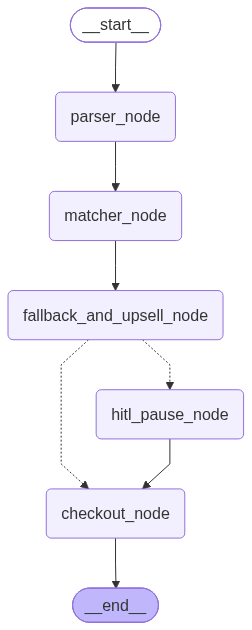

In [41]:
from typing import TypedDict, List, Dict, Any, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
import time
import os
import razorpay
from IPython.display import Image, display

# 1. Central Agent State
class AgentState(TypedDict):
    user_query: str
    spend_limit_inr: float
    dish_name: str
    is_cooking_or_baking: bool
    cart: List[Dict[str, Any]]
    missing_items: List[Dict[str, Any]]
    fallback_cart: List[Dict[str, Any]]
    upsell_item: Optional[Dict[str, Any]]
    total_inr: float
    is_approved: bool
    payment_link_url: Optional[str]
    audit_trace: List[str]

# 2. Razorpay Helper (Test Mode)
razorpay_client = razorpay.Client(
    auth=(os.getenv("RAZORPAY_KEY_ID", "rzp_test_placeholder"), 
          os.getenv("RAZORPAY_KEY_SECRET", "placeholder_secret"))
)

def generate_test_payment_link(amount_inr: float, description: str) -> str:
    amount_paise = int(amount_inr * 100)
    try:
        payload = {
            "amount": amount_paise,
            "currency": "INR",
            "accept_partial": False,
            "description": description,
            "customer": {"name": "NexusCart Buyer", "contact": "9999999999"},
            "notify": {"sms": False, "email": False},
            "reminder_enable": False,
            "expire_by": int(time.time()) + 1800,
            "notes": {"track": "Track 1: Agentic Commerce"}
        }
        link = razorpay_client.payment_link.create(payload)
        return link.get("short_url", f"https://rzp.io/i/mock_test_{amount_paise}")
    except Exception:
        return f"https://rzp.io/i/mock_test_{amount_paise}"

# 3. Graph Nodes
def parser_node(state: AgentState) -> dict:
    parsed = recipe_chain.invoke({"user_query": state["user_query"]})
    return {
        "dish_name": parsed.dish_name,
        "is_cooking_or_baking": parsed.is_cooking_or_baking,
        "audit_trace": state.get("audit_trace", []) + [f"Parsed intent: {parsed.dish_name}"]
    }

def matcher_node(state: AgentState) -> dict:
    parsed = recipe_chain.invoke({"user_query": state["user_query"]})
    result = match_inventory_and_calculate(parsed.ingredients, MOCK_CATALOG)
    return {
        "cart": result["cart"],
        "missing_items": result["missing_items"],
        "total_inr": result["subtotal_inr"],
        "audit_trace": state.get("audit_trace", []) + [f"Primary store matched. Subtotal: ₹{result['subtotal_inr']}"]
    }

def fallback_and_upsell_node(state: AgentState) -> dict:
    fallback = run_qc_fallback(state["missing_items"], QUICK_COMMERCE_CATALOG)
    upsell = get_margin_upsell(state["is_cooking_or_baking"], MOCK_CATALOG)
    
    new_total = state["total_inr"] + fallback["recovered_subtotal_inr"]
    if upsell:
        new_total += upsell["price_inr"]
        
    return {
        "fallback_cart": fallback["recovered_cart"],
        "upsell_item": upsell,
        "total_inr": new_total,
        "audit_trace": state["audit_trace"] + [f"Fallback/Upsell applied. Grand total: ₹{new_total}"]
    }

def hitl_pause_node(state: AgentState) -> dict:
    # Pauses graph execution asking for human input
    user_decision = interrupt(f"Cart total ₹{state['total_inr']} exceeds limit ₹{state['spend_limit_inr']}. Type 'CONFIRM'.")
    
    if str(user_decision).strip().upper() == "CONFIRM":
        return {"is_approved": True, "audit_trace": state["audit_trace"] + ["HITL: Approved"]}
    return {"is_approved": False, "audit_trace": state["audit_trace"] + ["HITL: Cancelled"]}

def checkout_node(state: AgentState) -> dict:
    link = generate_test_payment_link(state["total_inr"], f"Order for {state['dish_name']}")
    return {
        "payment_link_url": link,
        "is_approved": True,
        "audit_trace": state["audit_trace"] + [f"Payment link generated: {link}"]
    }

# 4. Conditional Router
def check_limit_router(state: AgentState) -> Literal["hitl_pause_node", "checkout_node"]:
    # Route to HITL if total exceeds limit and not yet approved
    if state["total_inr"] > state["spend_limit_inr"] and not state.get("is_approved", False):
        return "hitl_pause_node"
    return "checkout_node"

# 5. Build and Compile Graph
workflow = StateGraph(AgentState)

workflow.add_node("parser_node", parser_node)
workflow.add_node("matcher_node", matcher_node)
workflow.add_node("fallback_and_upsell_node", fallback_and_upsell_node)
workflow.add_node("hitl_pause_node", hitl_pause_node)
workflow.add_node("checkout_node", checkout_node)

workflow.add_edge(START, "parser_node")
workflow.add_edge("parser_node", "matcher_node")
workflow.add_edge("matcher_node", "fallback_and_upsell_node")
workflow.add_conditional_edges("fallback_and_upsell_node", check_limit_router)
workflow.add_edge("hitl_pause_node", "checkout_node")
workflow.add_edge("checkout_node", END)

checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

print("NexusCart AI Graph compiled successfully!")
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
# 1. Setup the thread configuration for memory tracking
config = {"configurable": {"thread_id": "test_session_001"}}

# 2. Define the initial state (Intentionally low limit to trigger HITL)
initial_input = {
    "user_query": "I want to bake a chocolate cake for 4 people.",
    "spend_limit_inr": 200.0, 
    "is_approved": False,
    "audit_trace": []
}

# 3. Invoke the graph!
print("Running NexusCart AI Graph...\n")
output = app.invoke(initial_input, config=config)

# 4. Print the current state of the audit trace
print("--- LIVE AUDIT TRACE ---")
for trace in output.get("audit_trace", []):
    print(f"> {trace}")

print("\n--- NEXT STEPS ---")
if output.get("is_approved"):
    print(f"Payment Link Ready: {output.get('payment_link_url')}")
else:
    print("Graph execution is PAUSED waiting for your 'CONFIRM' input!")

Running NexusCart AI Graph...

--- LIVE AUDIT TRACE ---
> Parsed intent: chocolate cake
> Primary store matched. Subtotal: ₹20.0
> Fallback/Upsell applied. Grand total: ₹450.0

--- NEXT STEPS ---
Graph execution is PAUSED waiting for your 'CONFIRM' input!


In [44]:
from langgraph.types import Command

print("Resuming graph execution with human confirmation...\n")

# Pass the resume command to the exact same thread ID we used in Cell 7
final_output = app.invoke(Command(resume="CONFIRM"), config=config)

# Print the completed tamper-proof audit trace
print("--- FINAL AUDIT TRACE ---")
for trace in final_output.get("audit_trace", []):
    print(f"> {trace}")

# Display the final Razorpay URL
print("\n--- RAZORPAY CHECKOUT ---")
print(f"Total Approved: ₹{final_output.get('total_inr')}")
print(f"Secure Payment Link: {final_output.get('payment_link_url')}")

Resuming graph execution with human confirmation...

--- FINAL AUDIT TRACE ---
> Parsed intent: chocolate cake
> Primary store matched. Subtotal: ₹20.0
> Fallback/Upsell applied. Grand total: ₹450.0
> HITL: Approved
> Payment link generated: https://rzp.io/i/mock_test_45000

--- RAZORPAY CHECKOUT ---
Total Approved: ₹450.0
Secure Payment Link: https://rzp.io/i/mock_test_45000
